In [15]:
import pandas as pd
import numpy as np

In [3]:
Auto = pd.read_csv('Auto.csv')

In [9]:
Auto = pd.read_csv('Auto.data', delim_whitespace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_15028\2891344115.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Auto = pd.read_csv('Auto.data', delim_whitespace=True)


In [19]:
Auto = pd.read_csv('Auto.data',
na_values=['?'],
delim_whitespace=True)
Auto['horsepower'].sum()

C:\Users\user\AppData\Local\Temp\ipykernel_15028\2658126750.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Auto = pd.read_csv('Auto.data',


np.float64(40952.0)

In [25]:
Auto.shape

(397, 9)

In [21]:
Auto_new = Auto.dropna()
Auto_new.shape

(392, 9)

In [29]:
Auto_new

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [35]:
quantitative_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

In [39]:
for column in quantitative_columns:
    minimum_column = np.min(Auto_new[column])
    maximum_column = np.max(Auto_new[column])
    print(f"{column}: Min = {minimum_column}, Max = {maximum_column}, Range = [{minimum_column}, {maximum_column}]")

mpg: Min = 9.0, Max = 46.6, Range = [9.0, 46.6]
cylinders: Min = 3, Max = 8, Range = [3, 8]
displacement: Min = 68.0, Max = 455.0, Range = [68.0, 455.0]
horsepower: Min = 46.0, Max = 230.0, Range = [46.0, 230.0]
weight: Min = 1613.0, Max = 5140.0, Range = [1613.0, 5140.0]
acceleration: Min = 8.0, Max = 24.8, Range = [8.0, 24.8]
year: Min = 70, Max = 82, Range = [70, 82]


In [43]:
for column in quantitative_columns:
    mean_column = np.mean(Auto_new[column])
    std_column = np.std(Auto_new[column], ddof=1)
    print(f"{column}: Mean = {mean_column:.2f}, Std Dev = {std_column:.2f}")

mpg: Mean = 23.45, Std Dev = 7.81
cylinders: Mean = 5.47, Std Dev = 1.71
displacement: Mean = 194.41, Std Dev = 104.64
horsepower: Mean = 104.47, Std Dev = 38.49
weight: Mean = 2977.58, Std Dev = 849.40
acceleration: Mean = 15.54, Std Dev = 2.76
year: Mean = 75.98, Std Dev = 3.68


In [45]:
Auto_subset = Auto_new.drop(Auto_new.index[9:85])

print("--- Subset Data Statistics (Rows 10-85 Removed) ---")
for column in quantitative_columns:
    col_min = np.min(Auto_subset[column])
    col_max = np.max(Auto_subset[column])
    col_mean = np.mean(Auto_subset[column])
    col_std = np.std(Auto_subset[column], ddof=1)
    print(f"{column}: Range=[{col_min}, {col_max}], Mean={col_mean:.2f}, Std Dev={col_std:.2f}")


--- Subset Data Statistics (Rows 10-85 Removed) ---
mpg: Range=[11.0, 46.6], Mean=24.40, Std Dev=7.87
cylinders: Range=[3, 8], Mean=5.37, Std Dev=1.65
displacement: Range=[68.0, 455.0], Mean=187.24, Std Dev=99.68
horsepower: Range=[46.0, 230.0], Mean=100.72, Std Dev=35.71
weight: Range=[1649.0, 4997.0], Mean=2935.97, Std Dev=811.30
acceleration: Range=[8.5, 24.8], Mean=15.73, Std Dev=2.69
year: Range=[70, 82], Mean=77.15, Std Dev=3.11


In [49]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

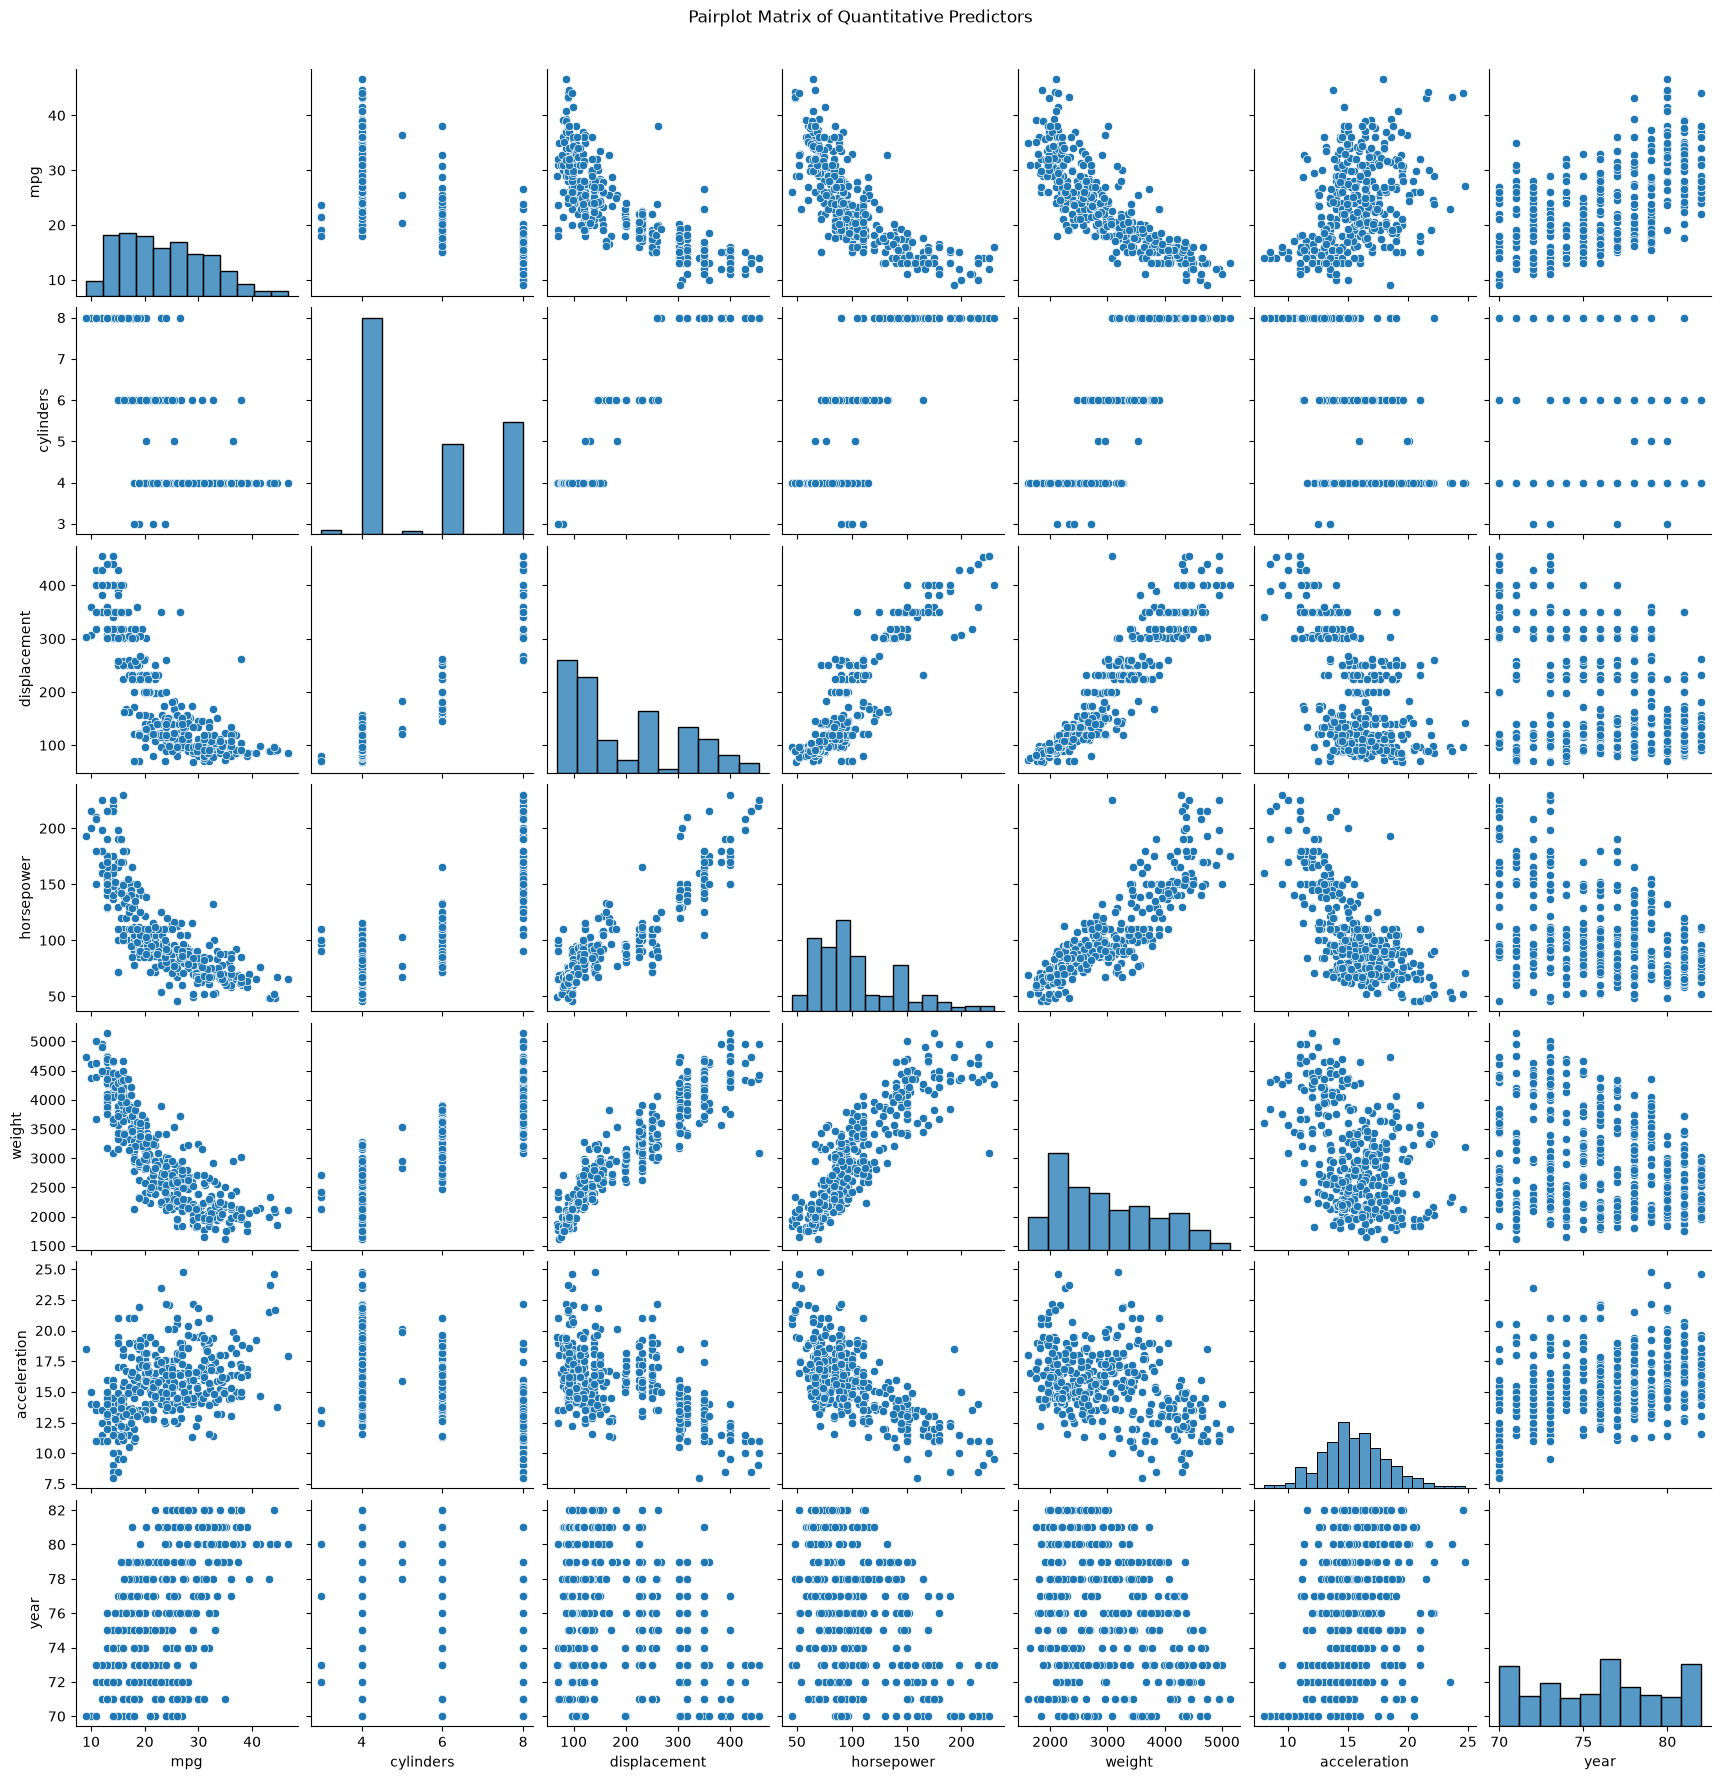

In [53]:
# Generate a grid of scatter plots for all quantitative predictors
sns.pairplot(Auto_new[quantitative_columns])
plt.suptitle("Pairplot Matrix of Quantitative Predictors", y=1.02)
plt.show()


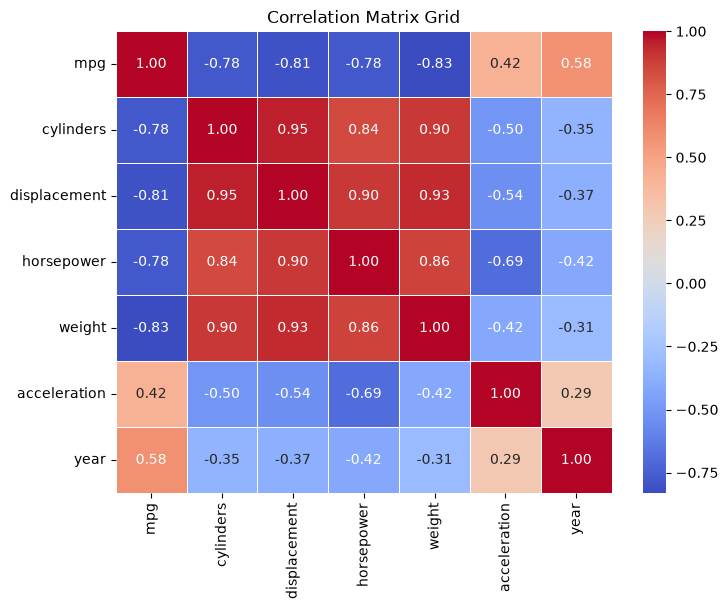

In [55]:
# Calculate correlation matrix
corr_matrix = Auto_new[quantitative_columns].corr()

# Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Grid")
plt.show()


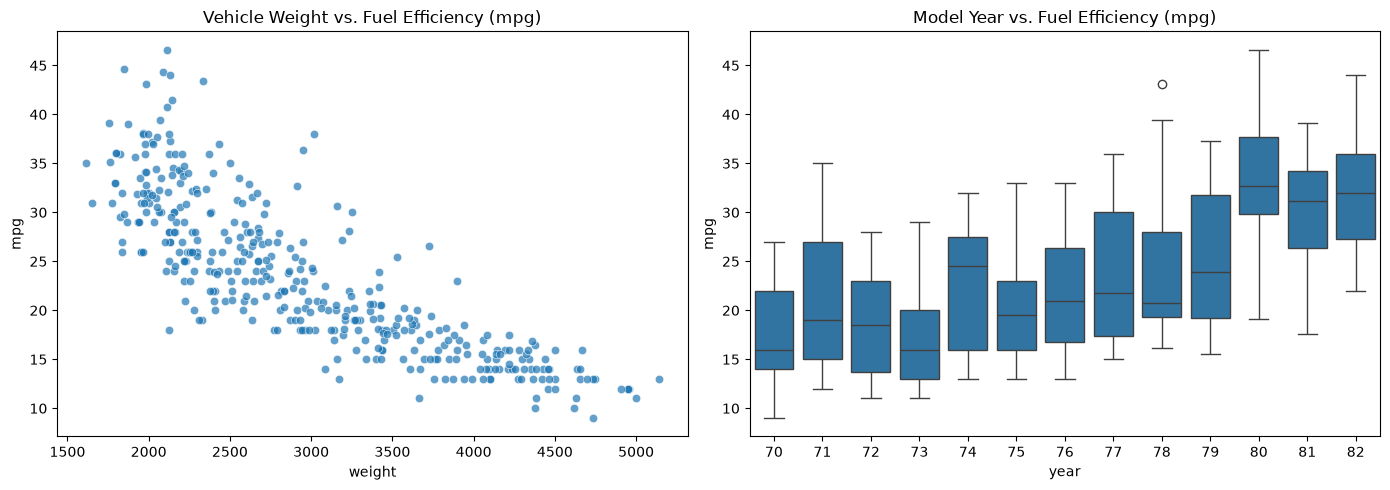

In [57]:
# Create a two-panel side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weight vs MPG (Inverted curve)
sns.scatterplot(data=Auto_new, x='weight', y='mpg', alpha=0.7, ax=axes[0])
axes[0].set_title("Vehicle Weight vs. Fuel Efficiency (mpg)")

# Plot 2: Year vs MPG (Upward historical trend)
sns.boxplot(data=Auto_new, x='year', y='mpg', ax=axes[1])
axes[1].set_title("Model Year vs. Fuel Efficiency (mpg)")

plt.tight_layout()
plt.show()


In [59]:
# For your pairplot cell:
plt.savefig('auto_pairplot.png', dpi=300, bbox_inches='tight')

# For your heatmap cell:
plt.savefig('auto_heatmap.png', dpi=300, bbox_inches='tight')

# For your side-by-side trends cell:
plt.savefig('auto_trends.png', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import statsmodels.api as sm

# Set random seed for reproducibility
np.random.seed(42)

# Part (b): Different Coefficients Example

x_b = np.random.normal(size=100)
y_b = 2 * x_b + np.random.normal(size=100)  # y is spread out much wider than x

# Fit OLS models without intercepts
model_yx_b = sm.OLS(y_b, x_b).fit()
model_xy_b = sm.OLS(x_b, y_b).fit()

print("--- Part (b) Results ---")
print(f"Sum of x^2: {np.sum(x_b**2):.2f} | Sum of y^2: {np.sum(y_b**2):.2f}")
print(f"Slope (Y onto X): {model_yx_b.params[0]:.4f}")
print(f"Slope (X onto Y): {model_xy_b.params[0]:.4f}\n")


# Part (c): Same Coefficients Example

x_c = np.random.normal(size=100)
# To guarantee sum(x^2) == sum(y^2), we just shuffle/reorder x to make y!
y_c = np.random.permutation(x_c) 

# Fit OLS models without intercepts
model_yx_c = sm.OLS(y_c, x_c).fit()
model_xy_c = sm.OLS(x_c, y_c).fit()

print("--- Part (c) Results ---")
print(f"Sum of x^2: {np.sum(x_c**2):.2f} | Sum of y^2: {np.sum(y_c**2):.2f}")
print(f"Slope (Y onto X): {model_yx_c.params[0]:.4f}")
print(f"Slope (X onto Y): {model_xy_c.params[0]:.4f}")


--- Part (b) Results ---
Sum of x^2: 82.73 | Sum of y^2: 373.30
Slope (Y onto X): 1.8558
Slope (X onto Y): 0.4113

--- Part (c) Results ---
Sum of x^2: 116.81 | Sum of y^2: 116.81
Slope (Y onto X): -0.0433
Slope (X onto Y): -0.0433
